In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,  classification_report

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

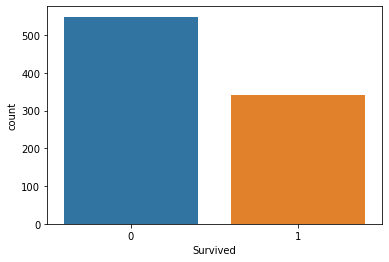

In [4]:
sns.countplot(x = 'Survived', data = df)
plt.show()

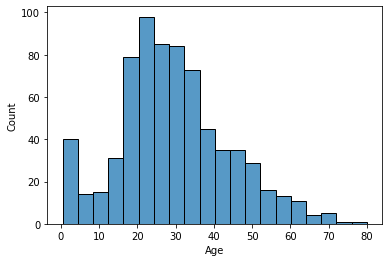

In [5]:
sns.histplot(df['Age'], bins = 20)
plt.show()

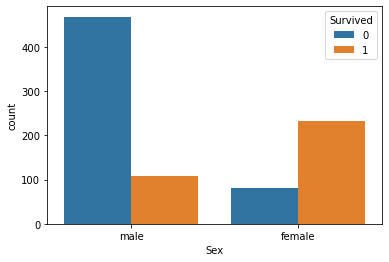

In [6]:
sns.countplot(x='Sex', hue='Survived',data=df)
plt.show()

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns = ['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [8]:
df.head()
df.isnull().sum()
df.dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

In [9]:
# One hot encoding

df = pd.get_dummies(df, columns = ['Sex', 'Embarked'], drop_first = True)

In [10]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=500)

In [13]:
lasso = LogisticRegression(penalty = 'l1', solver='liblinear', C=0.5 )
lasso.fit(X_train_scaled, y_train)

LogisticRegression(C=0.5, penalty='l1', solver='liblinear')

In [14]:
ridge = LogisticRegression(penalty = 'l2', C=0.5, max_iter = 500 )
ridge.fit(X_train_scaled, y_train)

LogisticRegression(C=0.5, max_iter=500)

In [15]:
# Evaluation

models = {'Baseline': lr, 'Lasso': lasso, 'Ridge': ridge}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n{name}")
    print("accuracy", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Baseline
accuracy 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179


Lasso
accuracy 0.7988826815642458
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


Ridge
accuracy 0.8044692737430168
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0